# Contains code related to the newly added features.

_features in v2_

---



In [ ]:
# basic essentials
import os
import dotenv
import gemini 

dotenv.load_dotenv()

True

## 1. PDF summarisation - 
_(using gemini long context ```[1m tokens or 700,000 words or 3600pages]```)_

In [5]:
from google import genai
from google.genai import types
import io
import httpx

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

long_context_pdf_path = "https://www.nasa.gov/wp-content/uploads/static/history/alsj/a17/A17_FlightPlan.pdf" # Replace with the actual URL of your large PDF

# Retrieve and upload the PDF using the File API
doc_io = io.BytesIO(httpx.get(long_context_pdf_path).content)

sample_doc = client.files.upload(
  file=doc_io, 
  config=dict(
    mime_type='application/pdf')
)

prompt = "Summarize this document"
response = client.models.generate_content(
  model="gemini-1.5-flash",
  contents=[sample_doc, prompt])
print(response.text)


This is the Apollo 17 Final Flight Plan, dated October 23, 1972.  The document is a highly detailed technical plan covering all aspects of the mission, from launch to splashdown.  It includes:

* **Detailed timelines:**  Chronological breakdowns of events for the Command Module (CSM) and Lunar Module (LM), including times, activities, and system status.  Separate timelines are included for various mission scenarios (e.g., contingency plans).

* **Tables and charts:**  Numerous tables and charts provide essential data regarding consumable usage (fuel, oxygen, water, batteries), communications coverage, TV schedules, suit wearing schedules, landmark tracking, and the Lunar Sounder's operational parameters.  Also included are photographic nomenclature specifications and a SIM experiment status code.

* **Systems descriptions:**  Sections detailing various spacecraft systems (CSM and LM), outlining communication protocols, electrical power systems, propulsion, guidance and navigation, and 

## 2. Mindmap generation
_(using gemini flash and mermaid)_

In [ ]:
topic = 'Global warming'
prompt = '''
Your are the best mindmap generator in the world.
For the given topic(s) generate all possible academically related subtopics and then create a mind map of the topic and its subtopics. 
The mindmap should be comprehensive, **CONCISE** and complete,
Return **ONLY** the mermaid code for the mind map. The mermaid code should be completely correct and should be able to generate the mind map without any further preprocessing.
'''

response = client.models.generate_content(
  model="gemini-1.5-flash",
  contents=[topic, prompt]
)
print(response.text)

```mermaid
mindmap
  root((Global Warming))
    sub("Causes")
      sub("Greenhouse Gas Emissions")
        sub("Fossil Fuel Combustion")
        sub("Deforestation")
        sub("Agriculture")
        sub("Industrial Processes")
        sub("Waste Management")
      sub("Natural Factors")
        sub("Volcanic Eruptions")
        sub("Solar Irradiance Variations")
        sub("Orbital Variations")
    sub("Effects")
      sub("Climate Change")
        sub("Rising Temperatures")
        sub("Sea Level Rise")
        sub("Ocean Acidification")
        sub("Extreme Weather Events")
          sub("Heatwaves")
          sub("Droughts")
          sub("Floods")
          sub("Hurricanes")
          sub("Wildfires")
      sub("Ecosystem Impacts")
        sub("Biodiversity Loss")
        sub("Habitat Disruption")
        sub("Species Extinction")
        sub("Changes in Migration Patterns")
      sub("Human Impacts")
        sub("Water Scarcity")
        sub("Food Security")
        sub("Healt

In [49]:
import base64
import io, requests
from IPython.display import Image, display
from PIL import Image as im
import matplotlib.pyplot as plt

def mm(graph):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    url = f'https://mermaid.ink/img/{base64_string}?theme=forest&width=1500&height=750&scale=3'
    print(url)
    img = im.open(io.BytesIO(requests.get(url).content))
    plt.imshow(img)
    plt.axis('off') # allow to hide axis
    plt.savefig('image.png', dpi=1200)

https://mermaid.ink/img/bWluZG1hcAogIHJvb3QoKEdsb2JhbCBXYXJtaW5nKSkKICAgIHN1YigiQ2F1c2VzIikKICAgICAgc3ViKCJHcmVlbmhvdXNlIEdhcyBFbWlzc2lvbnMiKQogICAgICAgIHN1YigiRm9zc2lsIEZ1ZWwgQ29tYnVzdGlvbiIpCiAgICAgICAgc3ViKCJEZWZvcmVzdGF0aW9uIikKICAgICAgICBzdWIoIkFncmljdWx0dXJlIikKICAgICAgICBzdWIoIkluZHVzdHJpYWwgUHJvY2Vzc2VzIikKICAgICAgICBzdWIoIldhc3RlIE1hbmFnZW1lbnQiKQogICAgICBzdWIoIk5hdHVyYWwgRmFjdG9ycyIpCiAgICAgICAgc3ViKCJWb2xjYW5pYyBFcnVwdGlvbnMiKQogICAgICAgIHN1YigiU29sYXIgSXJyYWRpYW5jZSBWYXJpYXRpb25zIikKICAgICAgICBzdWIoIk9yYml0YWwgVmFyaWF0aW9ucyIpCiAgICBzdWIoIkVmZmVjdHMiKQogICAgICBzdWIoIkNsaW1hdGUgQ2hhbmdlIikKICAgICAgICBzdWIoIlJpc2luZyBUZW1wZXJhdHVyZXMiKQogICAgICAgIHN1YigiU2VhIExldmVsIFJpc2UiKQogICAgICAgIHN1YigiT2NlYW4gQWNpZGlmaWNhdGlvbiIpCiAgICAgICAgc3ViKCJFeHRyZW1lIFdlYXRoZXIgRXZlbnRzIikKICAgICAgICAgIHN1YigiSGVhdHdhdmVzIikKICAgICAgICAgIHN1YigiRHJvdWdodHMiKQogICAgICAgICAgc3ViKCJGbG9vZHMiKQogICAgICAgICAgc3ViKCJIdXJyaWNhbmVzIikKICAgICAgICAgIHN1YigiV2lsZGZpcmVzIikKICAgICAgc3ViKCJFY29zeXN0ZW0gSW1w

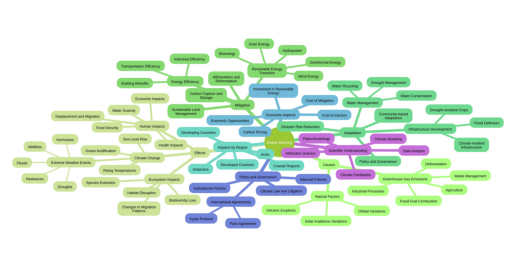

In [50]:
start_idx = response.text.find('mindmap')
mermaid_code = response.text[start_idx:-4]
# print(mermaid_code)
mm(mermaid_code)

## 3. Youtube video summarisation

_(using goated gemini feature of directly reading context of youtube video from the link)_

In [61]:
youtube_url = 'https://www.youtube.com/watch?v=6dTyOl1fmDo'

response = client.models.generate_content(
    model='models/gemini-2.0-flash',
    contents=types.Content(
        parts=[
            types.Part(text='Can you summarize this video?'),
            types.Part(
                file_data=types.FileData(file_uri=youtube_url)
            )
        ]
    )
)
print(response.text)

Sure, here's a summary of the video you shared:

The narrator revisits an old problem from a 2019 video, in which the collisions between two blocks compute π, and explains the secrets the narrator never revealed about it. After recapping the puzzle of the colliding blocks, including the masses of each of the blocks, the narrator explains that how all of this is actually connected to Quantum Computing, and in particular, Grover's Algorithm for Search. The narrator explains that many aspects have to be ideal to make this work, especially in terms of no energy being lost during collisions.

The narrator then explains that two of the laws of physics are involved with the puzzle, conservation of energy, and conservation of momentum. The energy is one-half of the mass times the velocity squared. Also, he translates and presents a geometric analysis of the problem. Finally, it’s stated that if people enjoyed this one, there’s another video to come next.
